In [2]:
 #importaing the necessary libraries
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#definding paths and load the first file 


raw_folder = Path("../data/raw/chb01")

# Pick the first file manually
file_path = raw_folder / "chb01_01.edf"

# Load EDF
raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

print("Loaded file:", file_path.name)
print(raw)

C:\Users\MSI\AppData\Local\Temp\ipykernel_11128\3456714373.py:16: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


Loaded file: chb01_01.edf
<RawEDF | chb01_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>


Visual inspection of raw signal
Using matplotlib as 2D backend.


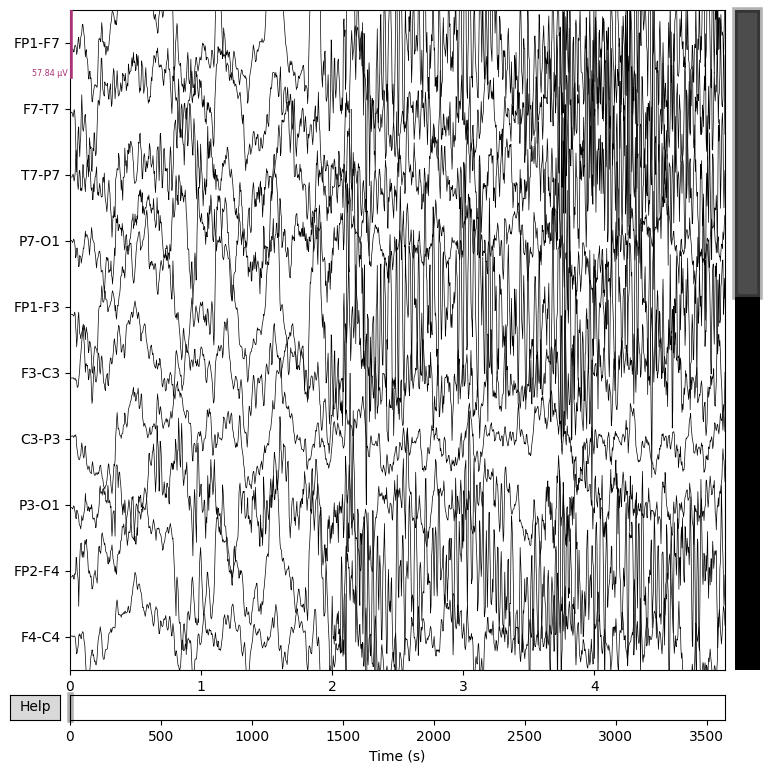

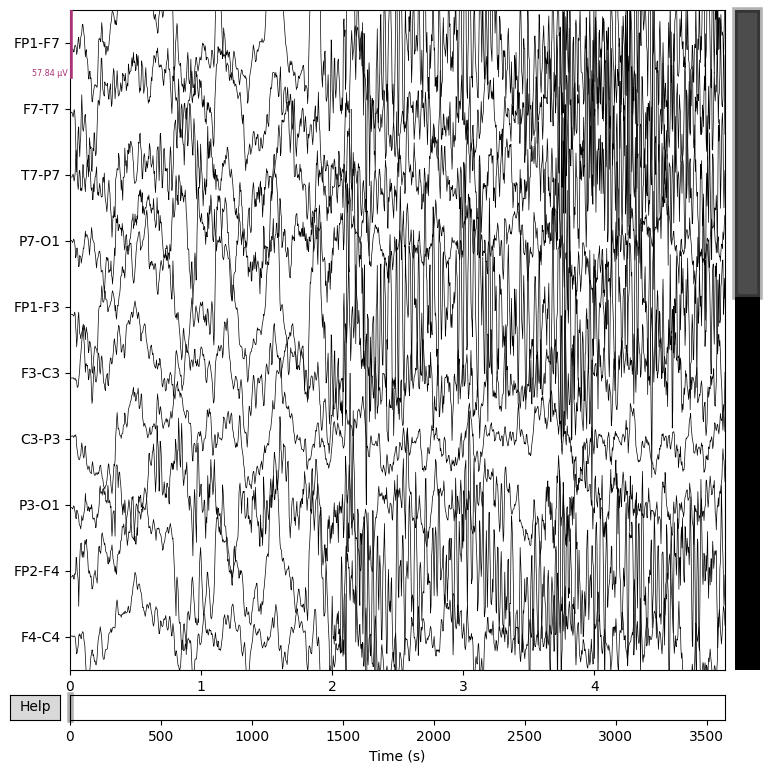

In [3]:
print("Visual inspection of raw signal")
raw.plot(duration=5, n_channels=10, scalings="auto")

In [4]:
#checking all the channel names 
print("Channel names:")
print(raw.ch_names)
print("Total number of channels:", len(raw.ch_names))

Channel names:
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
Total number of channels: 23


In [7]:
#keeping the EEG channels only 
eeg_channels = [ch for ch in raw.ch_names if "-" in ch]

print("EEG channels found:")
print(eeg_channels)
print("Number of EEG channels:", len(eeg_channels))

raw.pick(eeg_channels)
#checking the channel names after keeping only the EEG channels
print("Channels after keeping EEG only:")
print(raw.ch_names)

EEG channels found:
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
Number of EEG channels: 23
Channels after keeping EEG only:
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


In [ ]:
#this is very important to check the channel names and the number of channels in each file to ensure consistency across all files.
expected_channels = raw.ch_names.copy()

print("Expected channel set based on chb01_01:")
print(expected_channels)

Expected channel set based on chb01_01:
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


In [11]:
raw.set_channel_types({ch: "eeg" for ch in raw.ch_names})
print("Channel types after setting:")
print(raw.get_channel_types())

Channel types after setting:
['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']


In [ ]:
#checking the sampling frequency of the data 
sfreq = raw.info["sfreq"]
print("Sampling frequency:", sfreq)

Sampling frequency: 256.0


In [1]:
import mne
import numpy as np
import pandas as pd
from pathlib import Path

# =========================
# 1. Define folder and get all EDF files
# =========================
raw_folder = Path("../data/raw/chb01")
edf_files = sorted(raw_folder.glob("*.edf"))

print(f"Found {len(edf_files)} EDF files in {raw_folder}\n")
for f in edf_files:
    print(f.name)

# =========================
# 2. Collect metadata from all files
# =========================
all_file_info = []

for file_path in edf_files:
    try:
        raw_temp = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
        
        # keep only EEG-like channels using the same rule you used before
        eeg_channels = [ch for ch in raw_temp.ch_names if "-" in ch]
        
        file_info = {
            "file": file_path.name,
            "sfreq": raw_temp.info["sfreq"],
            "n_total_channels": len(raw_temp.ch_names),
            "n_eeg_channels": len(eeg_channels),
            "all_channels": raw_temp.ch_names,
            "eeg_channels": eeg_channels
        }
        
        all_file_info.append(file_info)
    
    except Exception as e:
        print(f"Error reading {file_path.name}: {e}")

# =========================
# 3. Use first file as reference
# =========================
reference_file = all_file_info[0]["file"]
reference_sfreq = all_file_info[0]["sfreq"]
reference_eeg_channels = all_file_info[0]["eeg_channels"]
reference_n_eeg_channels = all_file_info[0]["n_eeg_channels"]

print("\n" + "=" * 60)
print("REFERENCE FILE")
print("=" * 60)
print("File:", reference_file)
print("Sampling frequency:", reference_sfreq)
print("Number of EEG channels:", reference_n_eeg_channels)
print("EEG channels:")
print(reference_eeg_channels)

# =========================
# 4. Check consistency across all files
# =========================
consistency_rows = []

for info in all_file_info:
    same_sfreq = info["sfreq"] == reference_sfreq
    same_n_channels = info["n_eeg_channels"] == reference_n_eeg_channels
    same_channel_order = info["eeg_channels"] == reference_eeg_channels
    
    missing_channels = sorted(list(set(reference_eeg_channels) - set(info["eeg_channels"])))
    extra_channels = sorted(list(set(info["eeg_channels"]) - set(reference_eeg_channels)))
    
    consistency_rows.append({
        "file": info["file"],
        "sfreq": info["sfreq"],
        "matches_sfreq": same_sfreq,
        "n_eeg_channels": info["n_eeg_channels"],
        "matches_n_eeg_channels": same_n_channels,
        "matches_channel_order": same_channel_order,
        "missing_channels": ", ".join(missing_channels) if missing_channels else "",
        "extra_channels": ", ".join(extra_channels) if extra_channels else ""
    })

consistency_df = pd.DataFrame(consistency_rows)

print("\n" + "=" * 60)
print("CONSISTENCY SUMMARY TABLE")
print("=" * 60)
print(consistency_df)

# =========================
# 5. Print detailed differences only for problematic files
# =========================
problem_df = consistency_df[
    (~consistency_df["matches_sfreq"]) |
    (~consistency_df["matches_n_eeg_channels"]) |
    (~consistency_df["matches_channel_order"])
]

print("\n" + "=" * 60)
print("FILES WITH CONSISTENCY PROBLEMS")
print("=" * 60)

if len(problem_df) == 0:
    print("None - all files match the reference file.")
else:
    print(problem_df[[
        "file",
        "sfreq",
        "matches_sfreq",
        "n_eeg_channels",
        "matches_n_eeg_channels",
        "matches_channel_order",
        "missing_channels",
        "extra_channels"
    ]])

# =========================
# 6. Check duplicated base channel names
# =========================
# This helps you notice cases like T8-P8-0 and T8-P8-1
# We remove the trailing -0 / -1 only for checking duplicates
# =========================
def strip_duplicate_suffix(ch_name):
    if ch_name.endswith("-0") or ch_name.endswith("-1") or ch_name.endswith("-2") or ch_name.endswith("-3"):
        return ch_name[:-2]
    return ch_name

duplicate_rows = []

for info in all_file_info:
    base_names = [strip_duplicate_suffix(ch) for ch in info["eeg_channels"]]
    
    counts = {}
    for name in base_names:
        counts[name] = counts.get(name, 0) + 1
    
    duplicated = sorted([name for name, count in counts.items() if count > 1])
    
    duplicate_rows.append({
        "file": info["file"],
        "duplicated_base_channel_names": ", ".join(duplicated) if duplicated else ""
    })

duplicate_df = pd.DataFrame(duplicate_rows)

print("\n" + "=" * 60)
print("DUPLICATED BASE CHANNEL NAME CHECK")
print("=" * 60)
print(duplicate_df)

# =========================
# 7. Basic artifact screening across all files
# =========================
# This is a simple first-pass check, not a medical diagnosis.
# It flags channels with unusual variance compared to the others in the same file.
# =========================
artifact_rows = []

print("\n" + "=" * 60)
print("RUNNING BASIC ARTIFACT SCREENING")
print("=" * 60)

for file_path in edf_files:
    try:
        raw_temp = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
        
        eeg_channels = [ch for ch in raw_temp.ch_names if "-" in ch]
        raw_temp.pick(eeg_channels)
        
        data = raw_temp.get_data()
        
        channel_variances = np.var(data, axis=1)
        max_abs_amplitude = np.max(np.abs(data), axis=1)
        
        mean_var = np.mean(channel_variances)
        std_var = np.std(channel_variances)
        
        low_threshold = mean_var - 2 * std_var
        high_threshold = mean_var + 2 * std_var
        
        suspicious_channels = []
        
        for ch_name, var, amp in zip(raw_temp.ch_names, channel_variances, max_abs_amplitude):
            if var < low_threshold or var > high_threshold:
                suspicious_channels.append(f"{ch_name} (var={var:.10f}, max_amp={amp:.6f})")
        
        artifact_rows.append({
            "file": file_path.name,
            "n_eeg_channels": len(raw_temp.ch_names),
            "sfreq": raw_temp.info["sfreq"],
            "n_suspicious_channels": len(suspicious_channels),
            "suspicious_channels": " | ".join(suspicious_channels) if suspicious_channels else ""
        })
        
        print(f"Checked {file_path.name}")
    
    except Exception as e:
        print(f"Error during artifact screening for {file_path.name}: {e}")

artifact_df = pd.DataFrame(artifact_rows)

print("\n" + "=" * 60)
print("ARTIFACT SCREENING SUMMARY TABLE")
print("=" * 60)
print(artifact_df)

# =========================
# 8. Show only files with suspicious channels
# =========================
artifact_problem_df = artifact_df[artifact_df["n_suspicious_channels"] > 0]

print("\n" + "=" * 60)
print("FILES WITH SUSPICIOUS CHANNELS")
print("=" * 60)

if len(artifact_problem_df) == 0:
    print("None - no suspicious channels found by this simple rule.")
else:
    print(artifact_problem_df[["file", "n_suspicious_channels", "suspicious_channels"]])

# =========================
# 9. Optional: save summary tables to CSV
# =========================
output_folder = Path("../data/processed/chb01")
output_folder.mkdir(parents=True, exist_ok=True)

consistency_df.to_csv(output_folder / "chb01_consistency_check.csv", index=False)
duplicate_df.to_csv(output_folder / "chb01_duplicate_channel_check.csv", index=False)
artifact_df.to_csv(output_folder / "chb01_artifact_screening.csv", index=False)

print("\n" + "=" * 60)
print("CSV FILES SAVED")
print("=" * 60)
print(output_folder / "chb01_consistency_check.csv")
print(output_folder / "chb01_duplicate_channel_check.csv")
print(output_folder / "chb01_artifact_screening.csv")

Found 42 EDF files in ..\data\raw\chb01

chb01_01.edf
chb01_02.edf
chb01_03.edf
chb01_04.edf
chb01_05.edf
chb01_06.edf
chb01_07.edf
chb01_08.edf
chb01_09.edf
chb01_10.edf
chb01_11.edf
chb01_12.edf
chb01_13.edf
chb01_14.edf
chb01_15.edf
chb01_16.edf
chb01_17.edf
chb01_18.edf
chb01_19.edf
chb01_20.edf
chb01_21.edf
chb01_22.edf
chb01_23.edf
chb01_24.edf
chb01_25.edf
chb01_26.edf
chb01_27.edf
chb01_29.edf
chb01_30.edf
chb01_31.edf
chb01_32.edf
chb01_33.edf
chb01_34.edf
chb01_36.edf
chb01_37.edf
chb01_38.edf
chb01_39.edf
chb01_40.edf
chb01_41.edf
chb01_42.edf
chb01_43.edf
chb01_46.edf


C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\3572547496.py:23: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\3572547496.py:23: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\3572547496.py:23: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\3572547496.py:23: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(f


REFERENCE FILE
File: chb01_01.edf
Sampling frequency: 256.0
Number of EEG channels: 23
EEG channels:
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']

CONSISTENCY SUMMARY TABLE
            file  sfreq  matches_sfreq  n_eeg_channels  \
0   chb01_01.edf  256.0           True              23   
1   chb01_02.edf  256.0           True              23   
2   chb01_03.edf  256.0           True              23   
3   chb01_04.edf  256.0           True              23   
4   chb01_05.edf  256.0           True              23   
5   chb01_06.edf  256.0           True              23   
6   chb01_07.edf  256.0           True              23   
7   chb01_08.edf  256.0           True              23   
8   chb01_09.edf  256.0           True              23   
9   chb01_10.edf  256.0           True              23   
10  chb01_1

C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\3572547496.py:165: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


Checked chb01_02.edf


...

Checked chb01_42.edf


C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\3572547496.py:165: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


Checked chb01_43.edf


C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\3572547496.py:165: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


Checked chb01_46.edf

ARTIFACT SCREENING SUMMARY TABLE
            file  n_eeg_channels  sfreq  n_suspicious_channels  \
0   chb01_01.edf              23  256.0                      2   
1   chb01_02.edf              23  256.0                      2   
2   chb01_03.edf              23  256.0                      1   
3   chb01_04.edf              23  256.0                      1   
4   chb01_05.edf              23  256.0                      2   
5   chb01_06.edf              23  256.0                      2   
6   chb01_07.edf              23  256.0                      2   
7   chb01_08.edf              23  256.0                      2   
8   chb01_09.edf              23  256.0                      2   
9   chb01_10.edf              23  256.0                      1   
10  chb01_11.edf              23  256.0                      2   
11  chb01_12.edf              23  256.0                      2   
12  chb01_13.edf              23  256.0                      2   
13  chb01_14.edf     

In [2]:
import mne
import numpy as np
import pandas as pd
from pathlib import Path

# ==========================================================
# 1. Define main raw and processed folders
# ==========================================================
raw_root = Path("../data/raw")
processed_root = Path("../data/processed")

# Get all patient folders like chb01, chb02, ..., chb24
patient_folders = sorted([p for p in raw_root.glob("chb*") if p.is_dir()])

print(f"Found {len(patient_folders)} patient folders:\n")
for folder in patient_folders:
    print(folder.name)

# ==========================================================
# 2. Helper function to strip duplicate suffixes like -0 / -1
# ==========================================================
def strip_duplicate_suffix(ch_name):
    if ch_name.endswith("-0") or ch_name.endswith("-1") or ch_name.endswith("-2") or ch_name.endswith("-3"):
        return ch_name[:-2]
    return ch_name

# ==========================================================
# 3. Master summary list for all patients
# ==========================================================
all_patients_summary = []

# ==========================================================
# 4. Loop through every patient folder
# ==========================================================
for patient_folder in patient_folders:
    patient_name = patient_folder.name
    edf_files = sorted(patient_folder.glob("*.edf"))
    
    print("\n" + "=" * 80)
    print(f"PROCESSING PATIENT: {patient_name}")
    print("=" * 80)
    
    # Skip if no EDF files
    if len(edf_files) == 0:
        print(f"No EDF files found in {patient_name}. Skipping...")
        continue
    
    print(f"Found {len(edf_files)} EDF files in {patient_folder}")
    
    # Create processed folder for this patient
    output_folder = processed_root / patient_name
    output_folder.mkdir(parents=True, exist_ok=True)
    
    # ==========================================================
    # 4A. Collect metadata from all EDF files in this patient
    # ==========================================================
    all_file_info = []
    
    for file_path in edf_files:
        try:
            raw_temp = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
            
            # keep EEG-like channels only
            eeg_channels = [ch for ch in raw_temp.ch_names if "-" in ch]
            
            file_info = {
                "file": file_path.name,
                "sfreq": raw_temp.info["sfreq"],
                "n_total_channels": len(raw_temp.ch_names),
                "n_eeg_channels": len(eeg_channels),
                "all_channels": raw_temp.ch_names,
                "eeg_channels": eeg_channels
            }
            
            all_file_info.append(file_info)
        
        except Exception as e:
            print(f"Error reading {file_path.name}: {e}")
    
    # Skip if nothing could be loaded
    if len(all_file_info) == 0:
        print(f"No readable EDF files found in {patient_name}. Skipping...")
        continue
    
    # ==========================================================
    # 4B. Use first EDF file as reference
    # ==========================================================
    reference_file = all_file_info[0]["file"]
    reference_sfreq = all_file_info[0]["sfreq"]
    reference_eeg_channels = all_file_info[0]["eeg_channels"]
    reference_n_eeg_channels = all_file_info[0]["n_eeg_channels"]
    
    print("\nREFERENCE FILE")
    print("-" * 40)
    print("File:", reference_file)
    print("Sampling frequency:", reference_sfreq)
    print("Number of EEG channels:", reference_n_eeg_channels)
    
    # ==========================================================
    # 4C. Consistency check
    # ==========================================================
    consistency_rows = []
    
    for info in all_file_info:
        same_sfreq = info["sfreq"] == reference_sfreq
        same_n_channels = info["n_eeg_channels"] == reference_n_eeg_channels
        same_channel_order = info["eeg_channels"] == reference_eeg_channels
        
        missing_channels = sorted(list(set(reference_eeg_channels) - set(info["eeg_channels"])))
        extra_channels = sorted(list(set(info["eeg_channels"]) - set(reference_eeg_channels)))
        
        consistency_rows.append({
            "file": info["file"],
            "sfreq": info["sfreq"],
            "matches_sfreq": same_sfreq,
            "n_eeg_channels": info["n_eeg_channels"],
            "matches_n_eeg_channels": same_n_channels,
            "matches_channel_order": same_channel_order,
            "missing_channels": ", ".join(missing_channels) if missing_channels else "",
            "extra_channels": ", ".join(extra_channels) if extra_channels else ""
        })
    
    consistency_df = pd.DataFrame(consistency_rows)
    
    # ==========================================================
    # 4D. Duplicate base channel name check
    # ==========================================================
    duplicate_rows = []
    
    for info in all_file_info:
        base_names = [strip_duplicate_suffix(ch) for ch in info["eeg_channels"]]
        
        counts = {}
        for name in base_names:
            counts[name] = counts.get(name, 0) + 1
        
        duplicated = sorted([name for name, count in counts.items() if count > 1])
        
        duplicate_rows.append({
            "file": info["file"],
            "duplicated_base_channel_names": ", ".join(duplicated) if duplicated else ""
        })
    
    duplicate_df = pd.DataFrame(duplicate_rows)
    
    # ==========================================================
    # 4E. Basic artifact screening
    # ==========================================================
    artifact_rows = []
    
    print("\nRunning artifact screening...")
    
    for file_path in edf_files:
        try:
            raw_temp = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
            
            eeg_channels = [ch for ch in raw_temp.ch_names if "-" in ch]
            raw_temp.pick(eeg_channels)
            
            data = raw_temp.get_data()
            
            channel_variances = np.var(data, axis=1)
            max_abs_amplitude = np.max(np.abs(data), axis=1)
            
            mean_var = np.mean(channel_variances)
            std_var = np.std(channel_variances)
            
            low_threshold = mean_var - 2 * std_var
            high_threshold = mean_var + 2 * std_var
            
            suspicious_channels = []
            
            for ch_name, var, amp in zip(raw_temp.ch_names, channel_variances, max_abs_amplitude):
                if var < low_threshold or var > high_threshold:
                    suspicious_channels.append(f"{ch_name} (var={var:.10f}, max_amp={amp:.6f})")
            
            artifact_rows.append({
                "file": file_path.name,
                "n_eeg_channels": len(raw_temp.ch_names),
                "sfreq": raw_temp.info["sfreq"],
                "n_suspicious_channels": len(suspicious_channels),
                "suspicious_channels": " | ".join(suspicious_channels) if suspicious_channels else ""
            })
            
            print(f"Checked {file_path.name}")
        
        except Exception as e:
            print(f"Error during artifact screening for {file_path.name}: {e}")
    
    artifact_df = pd.DataFrame(artifact_rows)
    
    # ==========================================================
    # 4F. Save CSV files for this patient
    # ==========================================================
    consistency_df.to_csv(output_folder / f"{patient_name}_consistency_check.csv", index=False)
    duplicate_df.to_csv(output_folder / f"{patient_name}_duplicate_channel_check.csv", index=False)
    artifact_df.to_csv(output_folder / f"{patient_name}_artifact_screening.csv", index=False)
    
    # ==========================================================
    # 4G. Build short patient summary
    # ==========================================================
    problem_consistency_df = consistency_df[
        (~consistency_df["matches_sfreq"]) |
        (~consistency_df["matches_n_eeg_channels"]) |
        (~consistency_df["matches_channel_order"])
    ]
    
    problem_artifact_df = artifact_df[artifact_df["n_suspicious_channels"] > 0]
    
    duplicated_files_count = (duplicate_df["duplicated_base_channel_names"] != "").sum()
    
    patient_summary = {
        "patient": patient_name,
        "n_edf_files": len(edf_files),
        "reference_file": reference_file,
        "reference_sfreq": reference_sfreq,
        "reference_n_eeg_channels": reference_n_eeg_channels,
        "n_consistency_problem_files": len(problem_consistency_df),
        "n_files_with_duplicate_base_names": int(duplicated_files_count),
        "n_files_with_suspicious_channels": len(problem_artifact_df)
    }
    
    all_patients_summary.append(patient_summary)
    
    # ==========================================================
    # 4H. Print short summary for this patient
    # ==========================================================
    print("\nPATIENT SUMMARY")
    print("-" * 40)
    print(f"Patient: {patient_name}")
    print(f"EDF files: {len(edf_files)}")
    print(f"Reference file: {reference_file}")
    print(f"Reference sampling frequency: {reference_sfreq}")
    print(f"Reference EEG channel count: {reference_n_eeg_channels}")
    print(f"Files with consistency problems: {len(problem_consistency_df)}")
    print(f"Files with duplicate base channel names: {duplicated_files_count}")
    print(f"Files with suspicious channels: {len(problem_artifact_df)}")
    print("\nSaved files:")
    print(output_folder / f"{patient_name}_consistency_check.csv")
    print(output_folder / f"{patient_name}_duplicate_channel_check.csv")
    print(output_folder / f"{patient_name}_artifact_screening.csv")

# ==========================================================
# 5. Save overall summary for all patients
# ==========================================================
summary_df = pd.DataFrame(all_patients_summary)

summary_output = processed_root / "all_patients_summary_check.csv"
summary_df.to_csv(summary_output, index=False)

print("\n" + "=" * 80)
print("ALL PATIENTS SUMMARY")
print("=" * 80)
print(summary_df)

print("\nSaved overall summary to:")
print(summary_output)

Found 24 patient folders:

chb01
chb02
chb03
chb04
chb05
chb06
chb07
chb08
chb09
chb10
chb11
chb12
chb13
chb14
chb15
chb16
chb17
chb18
chb19
chb20
chb21
chb22
chb23
chb24

PROCESSING PATIENT: chb01
Found 42 EDF files in ..\data\raw\chb01

REFERENCE FILE
----------------------------------------
File: chb01_01.edf
Sampling frequency: 256.0
Number of EEG channels: 23

Running artifact screening...


C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\983150367.py:61: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\983150367.py:61: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\983150367.py:61: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\983150367.py:61: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(file_

Checked chb01_01.edf


C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\983150367.py:155: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


Checked chb01_02.edf


...

C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\983150367.py:155: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


Checked chb24_20.edf


C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\983150367.py:155: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


Checked chb24_21.edf
Checked chb24_22.edf

PATIENT SUMMARY
----------------------------------------
Patient: chb24
EDF files: 22
Reference file: chb24_01.edf
Reference sampling frequency: 256.0
Reference EEG channel count: 23
Files with consistency problems: 0
Files with duplicate base channel names: 22
Files with suspicious channels: 20

Saved files:
..\data\processed\chb24\chb24_consistency_check.csv
..\data\processed\chb24\chb24_duplicate_channel_check.csv
..\data\processed\chb24\chb24_artifact_screening.csv

ALL PATIENTS SUMMARY
   patient  n_edf_files reference_file  reference_sfreq  \
0    chb01           42   chb01_01.edf            256.0   
1    chb02           36   chb02_01.edf            256.0   
2    chb03           38   chb03_01.edf            256.0   
3    chb04           42   chb04_01.edf            256.0   
4    chb05           39   chb05_01.edf            256.0   
5    chb06           18   chb06_01.edf            256.0   
6    chb07           19   chb07_01.edf          

C:\Users\MSI\AppData\Local\Temp\ipykernel_26940\983150367.py:155: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_temp = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
